In [2]:
pip install scipy arviz

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import scipy as sp
import arviz as az

## Análisis exploratorio  de operaciones T0 y T1.

Cambios en las disteribuciones por variable con y sin fraude.


In [4]:
##pip install --upgrade --force-reinstall pyarrow pandas

In [5]:
operaciones_T0 = pd.read_parquet("/Users/Usuario/Downloads/operaciones_T0_train.parquet")

In [6]:
operaciones_T0

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,1,1,atm,noche,conocido,10.302010,0.065214,3,True,False
1,2,1,online,tarde,conocido,8.740580,0.181161,2,True,False
2,3,1,online,tarde,conocido,7.807675,0.361172,3,True,False
3,4,1,online,manana,registrado_reciente,7.084236,0.086316,2,True,False
4,5,1,online,tarde,registrado_reciente,9.144403,0.384047,2,True,False
...,...,...,...,...,...,...,...,...,...,...
420455,601285,12,atm,manana,conocido,8.557852,0.200289,4,True,False
420456,601288,12,atm,tarde,desconocido,6.477512,0.286038,3,True,False
420457,601289,12,presencial,noche,conocido,8.734331,0.244435,2,True,False
420458,601291,12,online,manana,conocido,9.127683,0.142148,6,True,False


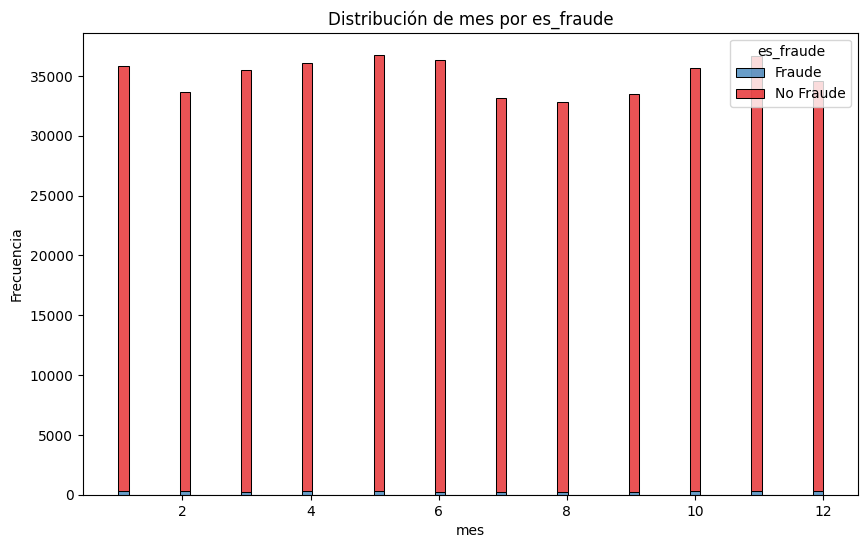

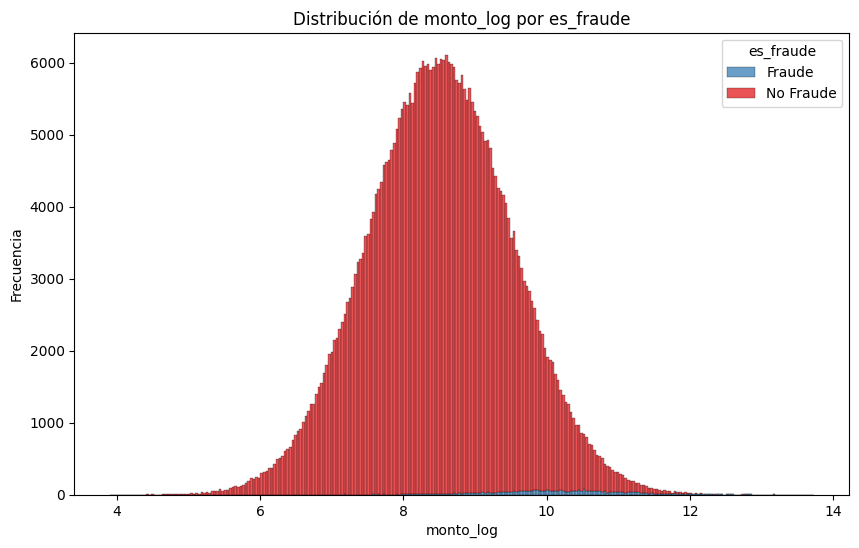

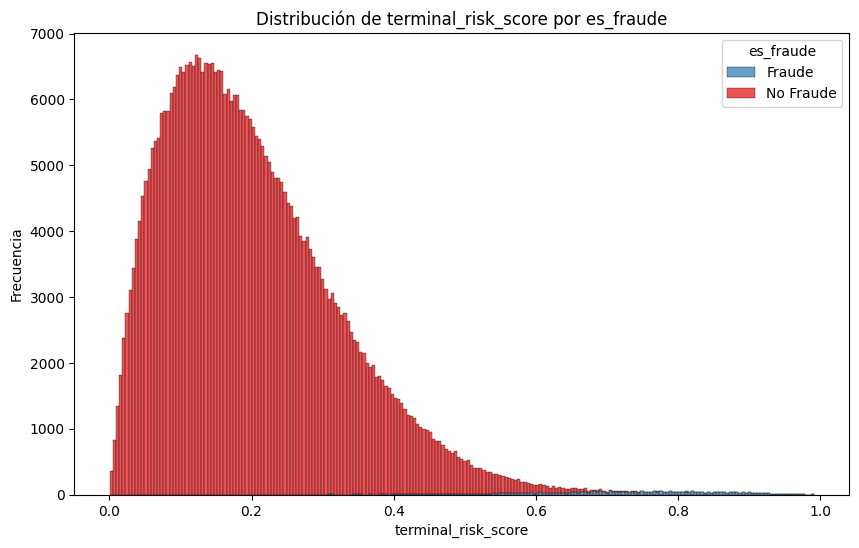

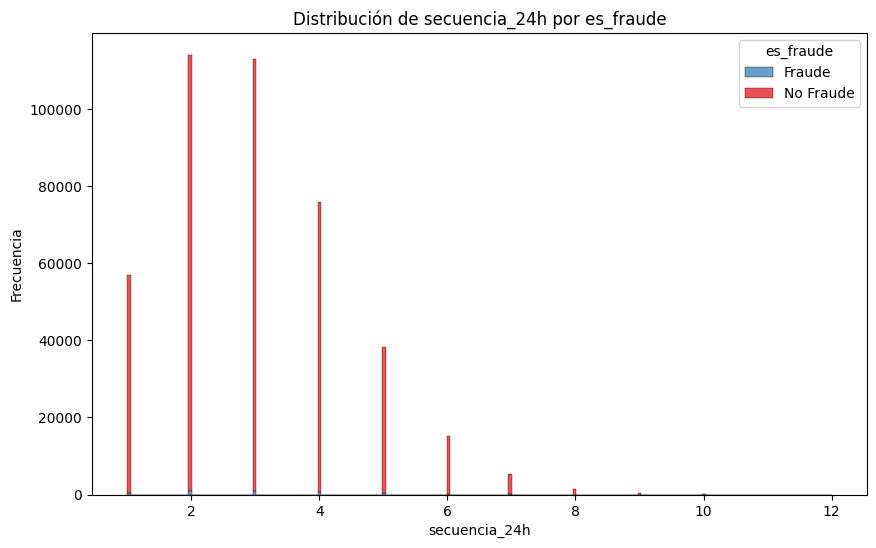

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# graficar la distribución de todas las variables numéricas comparadas con  es_fraude, incluir  % de fraude = true en cada grupo,  valor sobre cada barra, y leyenda con el color de cada barra


excluir = ['op_id']

numericas = operaciones_T0.select_dtypes(include=['number']).drop(columns=excluir)
for col in numericas.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=operaciones_T0, x=col, hue='es_fraude', multiple='stack', palette='Set1')
    plt.title(f'Distribución de {col} por es_fraude')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend(title='es_fraude', labels=['Fraude', 'No Fraude'])
    plt.show()

/var/folders/qr/_41v3jsx7cg7lcrljpp12fj80000gp/T/ipykernel_979/2111189019.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = operaciones_T0.select_dtypes(include=['object', 'category'])


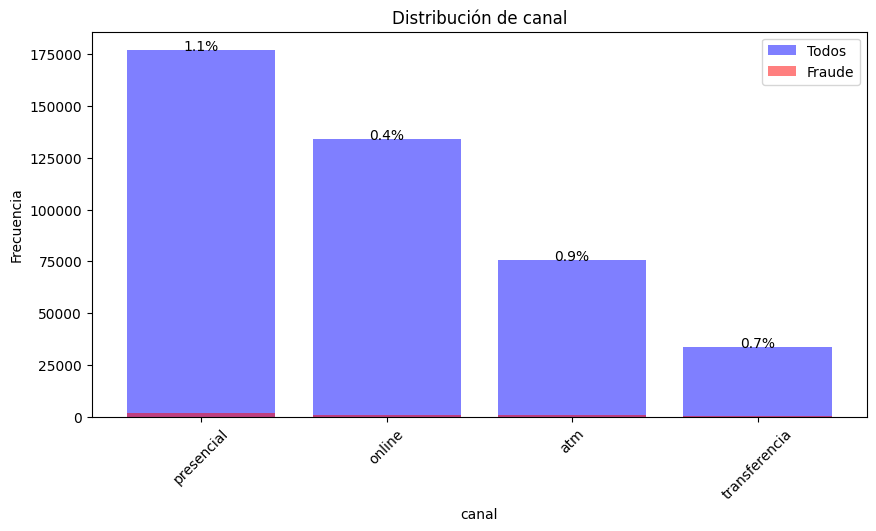

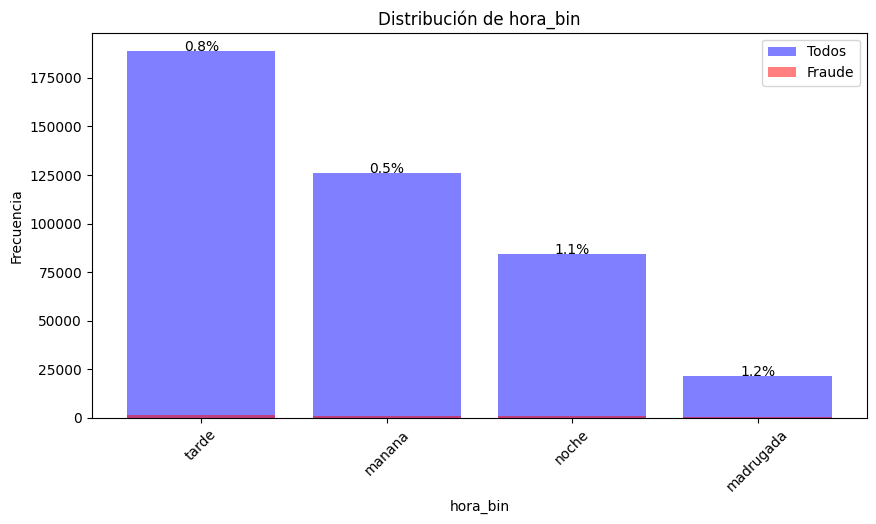

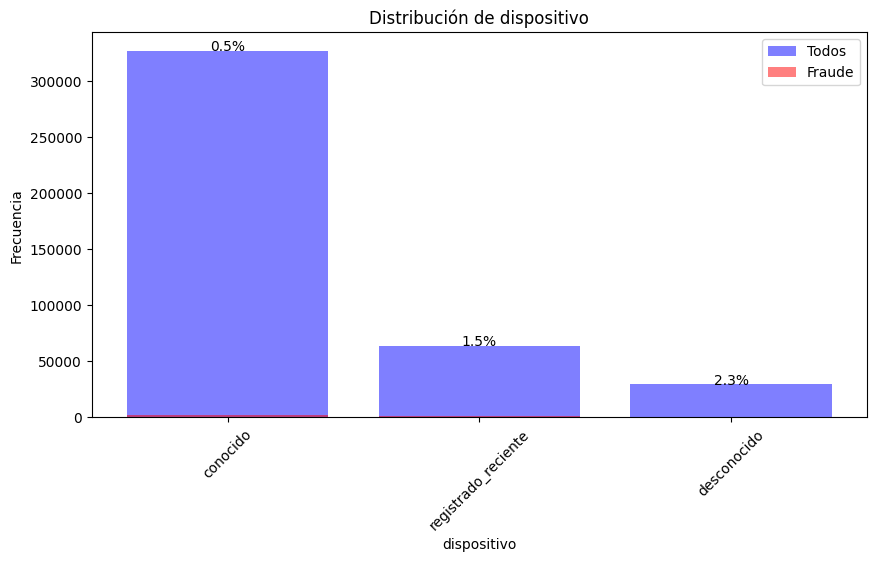

In [8]:
# Categoricas  comparadas con  es_fraude, incluir  % de cada categoria en cada grupo

categoricas = operaciones_T0.select_dtypes(include=['object', 'category'])
for col in categoricas.columns:
    plt.figure(figsize=(10, 5))
    total_counts = operaciones_T0[col].value_counts()
    fraude_counts = operaciones_T0[operaciones_T0['es_fraude'] == 1][col].value_counts()
    
    # Calcular porcentajes
    fraude_percentages = (fraude_counts / total_counts) * 100
    
    # Graficar barras
    plt.bar(total_counts.index, total_counts.values, alpha=0.5, label='Todos', color='blue')
    plt.bar(fraude_counts.index, fraude_counts.values, alpha=0.5, label='Fraude', color='red')
    
    # Agregar etiquetas de porcentaje
    for i, (total, fraude) in enumerate(zip(total_counts.values, fraude_counts.values)):
        percentage = fraude_percentages.get(total_counts.index[i], 0)
        plt.text(i, total + 5, f'{percentage:.1f}%', ha='center')
    
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [9]:
# Mismo análisis en T01

operaciones_T1_etiquetadas = pd.read_parquet("/Users/Usuario/Downloads/operaciones_T1_etiquetadas.parquet")

In [10]:
operaciones_T1_etiquetadas

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,601296,13,presencial,tarde,registrado_reciente,9.739413,0.316095,1,True,False
1,601297,13,online,manana,conocido,8.348123,0.076566,2,True,False
2,601298,13,atm,tarde,conocido,7.679568,0.035412,2,True,False
3,601299,13,presencial,manana,conocido,8.165072,0.053509,2,True,False
4,601304,13,presencial,noche,registrado_reciente,10.537983,0.222534,2,True,False
...,...,...,...,...,...,...,...,...,...,...
180360,1202651,24,transferencia,tarde,conocido,9.535509,0.213133,1,True,False
180361,1202652,24,atm,noche,conocido,7.554811,0.191474,4,True,False
180362,1202663,24,presencial,noche,conocido,9.058766,0.076800,1,True,False
180363,1202665,24,presencial,noche,conocido,8.636990,0.533654,4,True,False


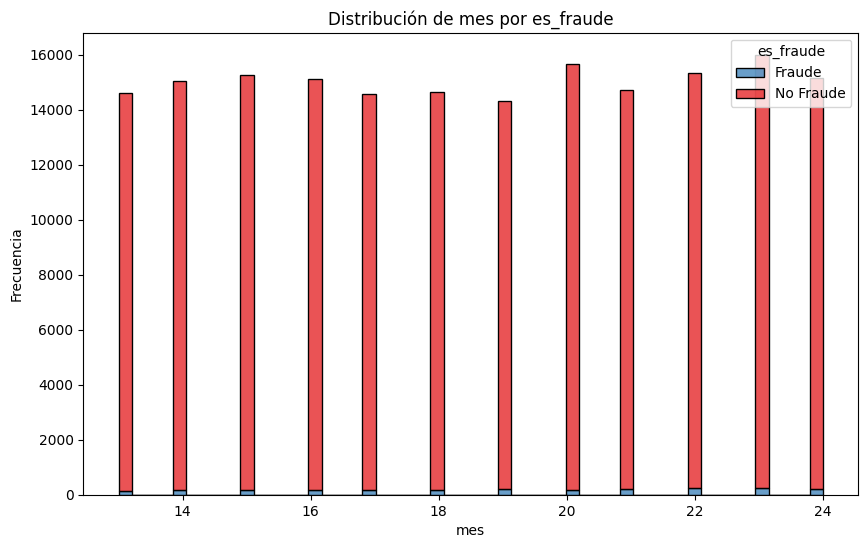

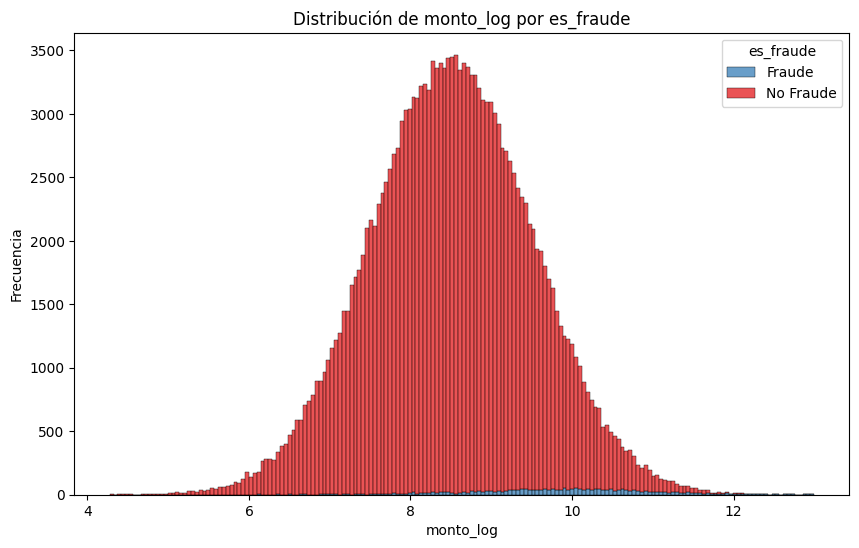

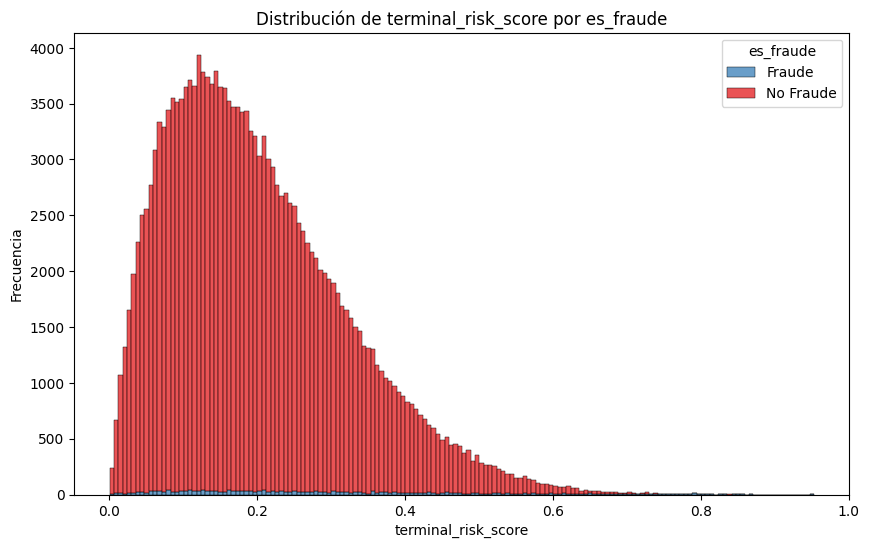

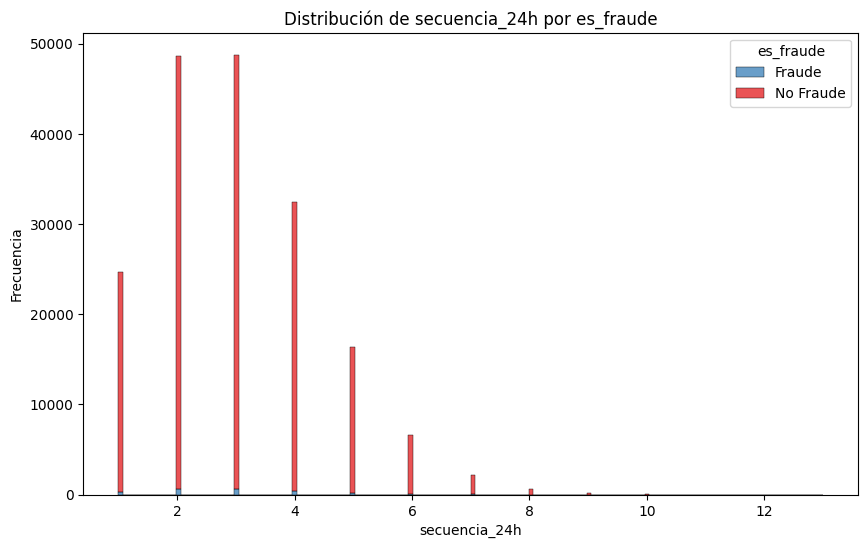

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# graficar la distribución de todas las variables numéricas comparadas con  es_fraude, incluir  % de fraude = true en cada grupo,  valor sobre cada barra, y leyenda con el color de cada barra


excluir = ['op_id']

numericas = operaciones_T1_etiquetadas.select_dtypes(include=['number']).drop(columns=excluir)
for col in numericas.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=operaciones_T1_etiquetadas, x=col, hue='es_fraude', multiple='stack', palette='Set1')
    plt.title(f'Distribución de {col} por es_fraude')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend(title='es_fraude', labels=['Fraude', 'No Fraude'])
    plt.show()

/var/folders/qr/_41v3jsx7cg7lcrljpp12fj80000gp/T/ipykernel_979/33196384.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = operaciones_T1_etiquetadas.select_dtypes(include=['object', 'category'])


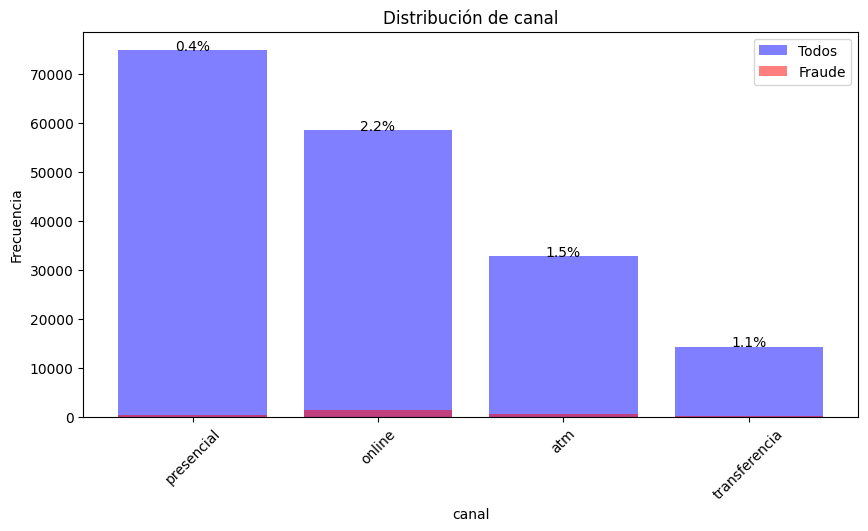

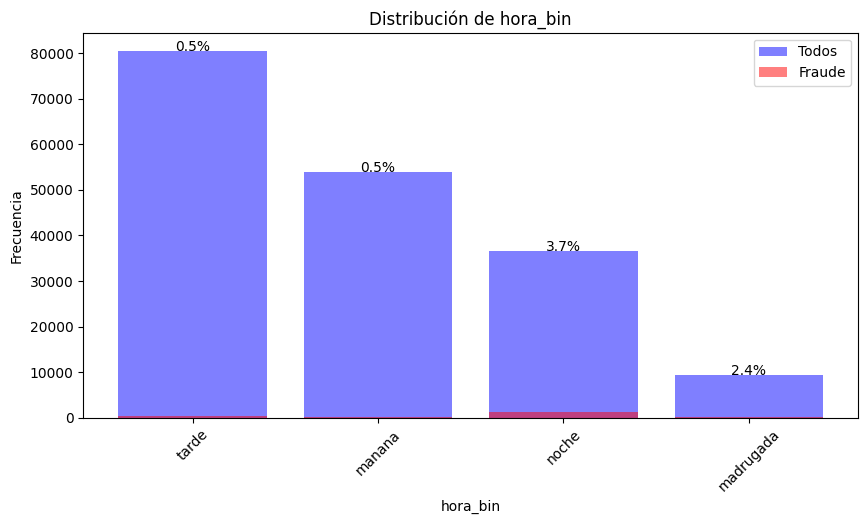

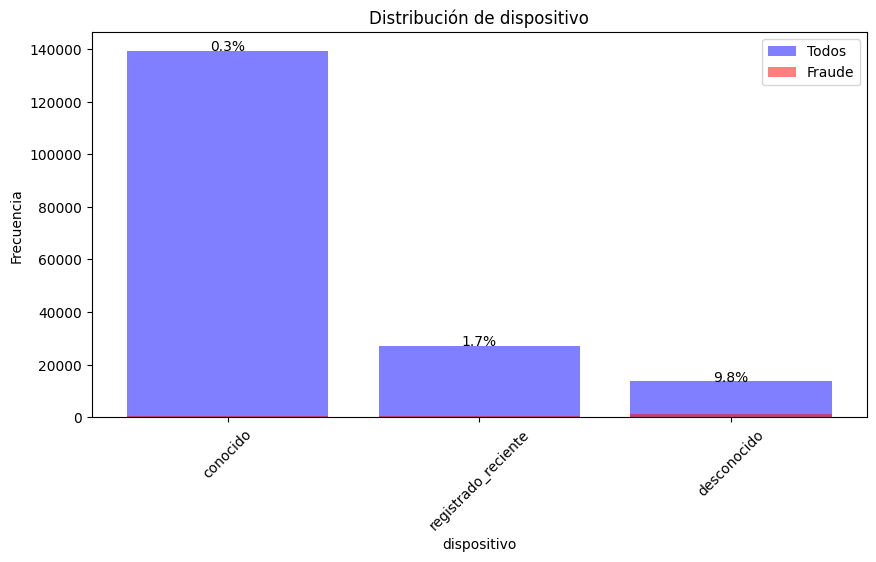

In [12]:
# Categoricas  comparadas con  es_fraude, incluir  % de cada categoria en cada grupo

categoricas = operaciones_T1_etiquetadas.select_dtypes(include=['object', 'category'])
for col in categoricas.columns:
    plt.figure(figsize=(10, 5))
    total_counts = operaciones_T1_etiquetadas[col].value_counts()
    fraude_counts = operaciones_T1_etiquetadas[operaciones_T1_etiquetadas['es_fraude'] == 1][col].value_counts()
    
    # Calcular porcentajes
    fraude_percentages = (fraude_counts / total_counts) * 100
    
    # Graficar barras
    plt.bar(total_counts.index, total_counts.values, alpha=0.5, label='Todos', color='blue')
    plt.bar(fraude_counts.index, fraude_counts.values, alpha=0.5, label='Fraude', color='red')
    
    # Agregar etiquetas de porcentaje
    for i, (total, fraude) in enumerate(zip(total_counts.values, fraude_counts.values)):
        percentage = fraude_percentages.get(total_counts.index[i], 0)
        plt.text(i, total + 5, f'{percentage:.1f}%', ha='center')
    
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [13]:
## Cambio totalmente el comportamiento:

## Describir los cambios

In [14]:
import pickle

ruta = "/Users/Usuario/Downloads/banco-anfora-bayes-fraud/Modelos/M1_logistica.pkl"

with open(ruta, "rb") as f:
    M1 = pickle.load(f)

print(type(M1))

<class 'dict'>


In [15]:
M1

{'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num', 'passthrough',
                                                   ['monto_log']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['canal', 'dispositivo'])])),
                 ('clf',
                  LogisticRegression(max_iter=1000, random_state=20260424))]),
 'features': ['monto_log', 'canal', 'dispositivo'],
 'threshold': 0.14}

In [16]:
import pandas as pd

metricas_T0_validacion = pd.read_json("/Users/Usuario/Downloads/banco-anfora-bayes-fraud/Operaciones/metricas_T0_validacion.json", orient="index")


metricas_T0_validacion

,descripcion,features,threshold,T0_train,T0_validacion
M1_logistica,Regresión logística lineal con 3 features (mon...,"[monto_log, canal, dispositivo]",0.14,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M2_random_forest,Random Forest con 5 features (incluye hora_bin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M3_gbm_completo,Gradient Boosting completo con 6 features incl...,"[monto_log, secuencia_24h, terminal_risk_score...",0.46,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M4_gbm_moderado,Gradient Boosting moderado con 5 features (sin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M5_naive_bayes,Naive Bayes Gaussiano con solo 2 features estr...,"[monto_log, secuencia_24h]",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."


In [17]:
# Convertir una columna con un diccionario a columnas separadas: 

Metricas_T0_Val = metricas_T0_validacion['T0_validacion'].apply(pd.Series)

In [18]:
Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176


In [19]:
# sanity check: verificar que las métricas se correspondan con las del modelo M1:

def f1_score(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)


In [20]:
# Quiero agregar una coluna con el f1_score recalculado a partir de precision y recall para cada fila

Metricas_T0_Val['f1_score_recalculada'] = Metricas_T0_Val.apply(lambda row: f1_score(row['precision'], row['recall']), axis=1)

In [21]:
Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr,f1_score_recalculada
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716,0.242657
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155,0.243461
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691,0.841804
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068,0.235821
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176,0.213592


## Paso 2. Primer posterior Beta-Binomial sobre un solo modelo
Tomar M3 y la validación T0 entera. 

#### Construir dos posteriores Beta-Binomial conjugadas: 
    una sobre la precisión, p | datos ∼ Beta(1 + TP, 1 + FP), 
    y otra sobre la sensibilidad, r | datos ∼ Beta(1 + TP, 1 + FN). 
    
    Con prior uniforme Beta(1, 1), esa es la actualización conjugada estándar.

Reportar mediana y HPDI 95 % de cada una.

Lo importante de este paso no es el número en sí sino tener dos cosas claras: 
(i) por qué la elección Beta-Binomial es natural — el dato es una secuencia de éxitos y fracasos, y la
posterior conjugada es Beta; 

(ii) qué supone la posterior — que precisión y sensibilidad son?

In [22]:
# operaciones_T0_valid = pd.read_parquet("/Users/Usuario/Downloads/banco-anfora-bayes-fraud/Operaciones/operaciones_T0_valid.parquet")

# metricas_temporales = pd.read_csv("/Users/Usuario/Downloads/metricas_temporales.csv")

In [23]:
#### Construir dos posteriores Beta-Binomial conjugadas: 
# una sobre la precisión, p | datos ∼ Beta(1 + TP, 1 + FP), 
# y otra sobre la sensibilidad, r | datos ∼ Beta(1 + TP, 1 + FN). 
# Con prior uniforme Beta(1, 1), esa es la actualización conjugada estándar.

Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr,f1_score_recalculada
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716,0.242657
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155,0.243461
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691,0.841804
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068,0.235821
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176,0.213592


In [24]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt


# Prior
a_prior = 1
b_prior = 1

results = {}

for idx in range(len(Metricas_T0_Val)):
    model = Metricas_T0_Val.index[idx]

    # Datos
    TP = Metricas_T0_Val['TP'].iloc[idx]
    FP = Metricas_T0_Val['FP'].iloc[idx]
    FN = Metricas_T0_Val['FN'].iloc[idx]

    # Posterior
    a_post_P_i = a_prior + TP
    b_post_P_i = b_prior + FP

    a_post_R_i = a_prior + TP
    b_post_R_i = b_prior + FN

    x = np.linspace(0, 1, 100)

    prior_P = beta.pdf(x, a_prior, b_prior)
    posterior_P = beta.pdf(x, a_post_P_i, b_post_P_i)

    prior_R = beta.pdf(x, a_prior, b_prior)
    posterior_R = beta.pdf(x, a_post_R_i, b_post_R_i)

    results[model] = {
        "TP": TP, "FP": FP, "FN": FN,
        "a_post_P": a_post_P_i, "b_post_P": b_post_P_i,
        "a_post_R": a_post_R_i, "b_post_R": b_post_R_i,
        "x": x, "prior_P": prior_P, "posterior_P": posterior_P,
        "prior_R": prior_R, "posterior_R": posterior_R
    }






In [25]:
# Media y varianza posterior precisión

for model, res in results.items():
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    mean_P = a_post_P / (a_post_P + b_post_P)
    var_P = (a_post_P * b_post_P) / ((a_post_P + b_post_P)**2 * (a_post_P + b_post_P + 1))

    # Media y varianza posterior recall
    mean_R = a_post_R / (a_post_R + b_post_R)
    var_R = (a_post_R * b_post_R) / ((a_post_R + b_post_R)**2 * (a_post_R + b_post_R + 1))

    print(f"{model} - Precisión: Media={mean_P:.4f}, Varianza={var_P:.8f}")
    print(f"{model} - Recall: Media={mean_R:.4f}, Varianza={var_R:.8f}")
    print()



M1_logistica - Precisión: Media=0.2461, Varianza=0.00013112
M1_logistica - Recall: Media=0.2400, Varianza=0.00012571

M2_random_forest - Precisión: Media=0.2290, Varianza=0.00010686
M2_random_forest - Recall: Media=0.2607, Varianza=0.00013283

M3_gbm_completo - Precisión: Media=0.8731, Varianza=0.00008211
M3_gbm_completo - Recall: Media=0.8117, Varianza=0.00010533

M4_gbm_moderado - Precisión: Media=0.2080, Varianza=0.00008647
M4_gbm_moderado - Recall: Media=0.2731, Varianza=0.00013681

M5_naive_bayes - Precisión: Media=0.2013, Varianza=0.00009775
M5_naive_bayes - Recall: Media=0.2283, Varianza=0.00012141



In [26]:

# --------------------------
# Función para calcular HPDI
# --------------------------
def hpdi(samples, prob=0.95):
    samples = np.sort(samples)
    n = len(samples)
    interval_idx_inc = int(np.floor(prob * n))
    
    interval_width = samples[interval_idx_inc:] - samples[:n - interval_idx_inc]
    min_idx = np.argmin(interval_width)
    
    hdi_min = samples[min_idx]
    hdi_max = samples[min_idx + interval_idx_inc]
    
    return hdi_min, hdi_max

In [27]:
# Cantidad de simulaciones
S = 100_000

for model, res in results.items():
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    # -----------------------------
    # Precisión
    # -----------------------------
    mean_P = a_post_P / (a_post_P + b_post_P)
    var_P = (a_post_P * b_post_P) / (
        (a_post_P + b_post_P)**2 * (a_post_P + b_post_P + 1)
    )

    samples_P = beta.rvs(
        a_post_P,
        b_post_P,
        size=S,
        random_state=42
    )

    median_P = np.median(samples_P)
    hpdi_P = hpdi(samples_P, prob=0.95)

    # -----------------------------
    # Recall / Sensibilidad
    # -----------------------------
    mean_R = a_post_R / (a_post_R + b_post_R)
    var_R = (a_post_R * b_post_R) / (
        (a_post_R + b_post_R)**2 * (a_post_R + b_post_R + 1)
    )

    samples_R = beta.rvs(
        a_post_R,
        b_post_R,
        size=S,
        random_state=123
    )

    median_R = np.median(samples_R)
    hpdi_R = hpdi(samples_R, prob=0.95)

    # -----------------------------
    # Guardar resultados en el diccionario
    # -----------------------------
    results[model]["mean_P"] = mean_P
    results[model]["var_P"] = var_P
    results[model]["median_P"] = median_P
    results[model]["hpdi_P"] = hpdi_P

    results[model]["mean_R"] = mean_R
    results[model]["var_R"] = var_R
    results[model]["median_R"] = median_R
    results[model]["hpdi_R"] = hpdi_R

    # -----------------------------
    # Print
    # -----------------------------
    print(f"Modelo: {model}")

    print("Precisión")
    print(f"Media:    {mean_P:.4f}")
    print(f"Varianza: {var_P:.8f}")
    print(f"Mediana:  {median_P:.4f}")
    print(f"HPDI 95%: [{hpdi_P[0]:.4f}, {hpdi_P[1]:.4f}]")

    print("\nRecall / Sensibilidad")
    print(f"Media:    {mean_R:.4f}")
    print(f"Varianza: {var_R:.8f}")
    print(f"Mediana:  {median_R:.4f}")
    print(f"HPDI 95%: [{hpdi_R[0]:.4f}, {hpdi_R[1]:.4f}]")

    print("-" * 50)

Modelo: M1_logistica
Precisión
Media:    0.2461
Varianza: 0.00013112
Mediana:  0.2460
HPDI 95%: [0.2240, 0.2689]

Recall / Sensibilidad
Media:    0.2400
Varianza: 0.00012571
Mediana:  0.2398
HPDI 95%: [0.2180, 0.2618]
--------------------------------------------------
Modelo: M2_random_forest
Precisión
Media:    0.2290
Varianza: 0.00010686
Mediana:  0.2289
HPDI 95%: [0.2084, 0.2490]

Recall / Sensibilidad
Media:    0.2607
Varianza: 0.00013283
Mediana:  0.2606
HPDI 95%: [0.2387, 0.2837]
--------------------------------------------------
Modelo: M3_gbm_completo
Precisión
Media:    0.8731
Varianza: 0.00008211
Mediana:  0.8733
HPDI 95%: [0.8553, 0.8909]

Recall / Sensibilidad
Media:    0.8117
Varianza: 0.00010533
Mediana:  0.8118
HPDI 95%: [0.7915, 0.8315]
--------------------------------------------------
Modelo: M4_gbm_moderado
Precisión
Media:    0.2080
Varianza: 0.00008647
Mediana:  0.2079
HPDI 95%: [0.1893, 0.2258]

Recall / Sensibilidad
Media:    0.2731
Varianza: 0.00013681
Mediana: 

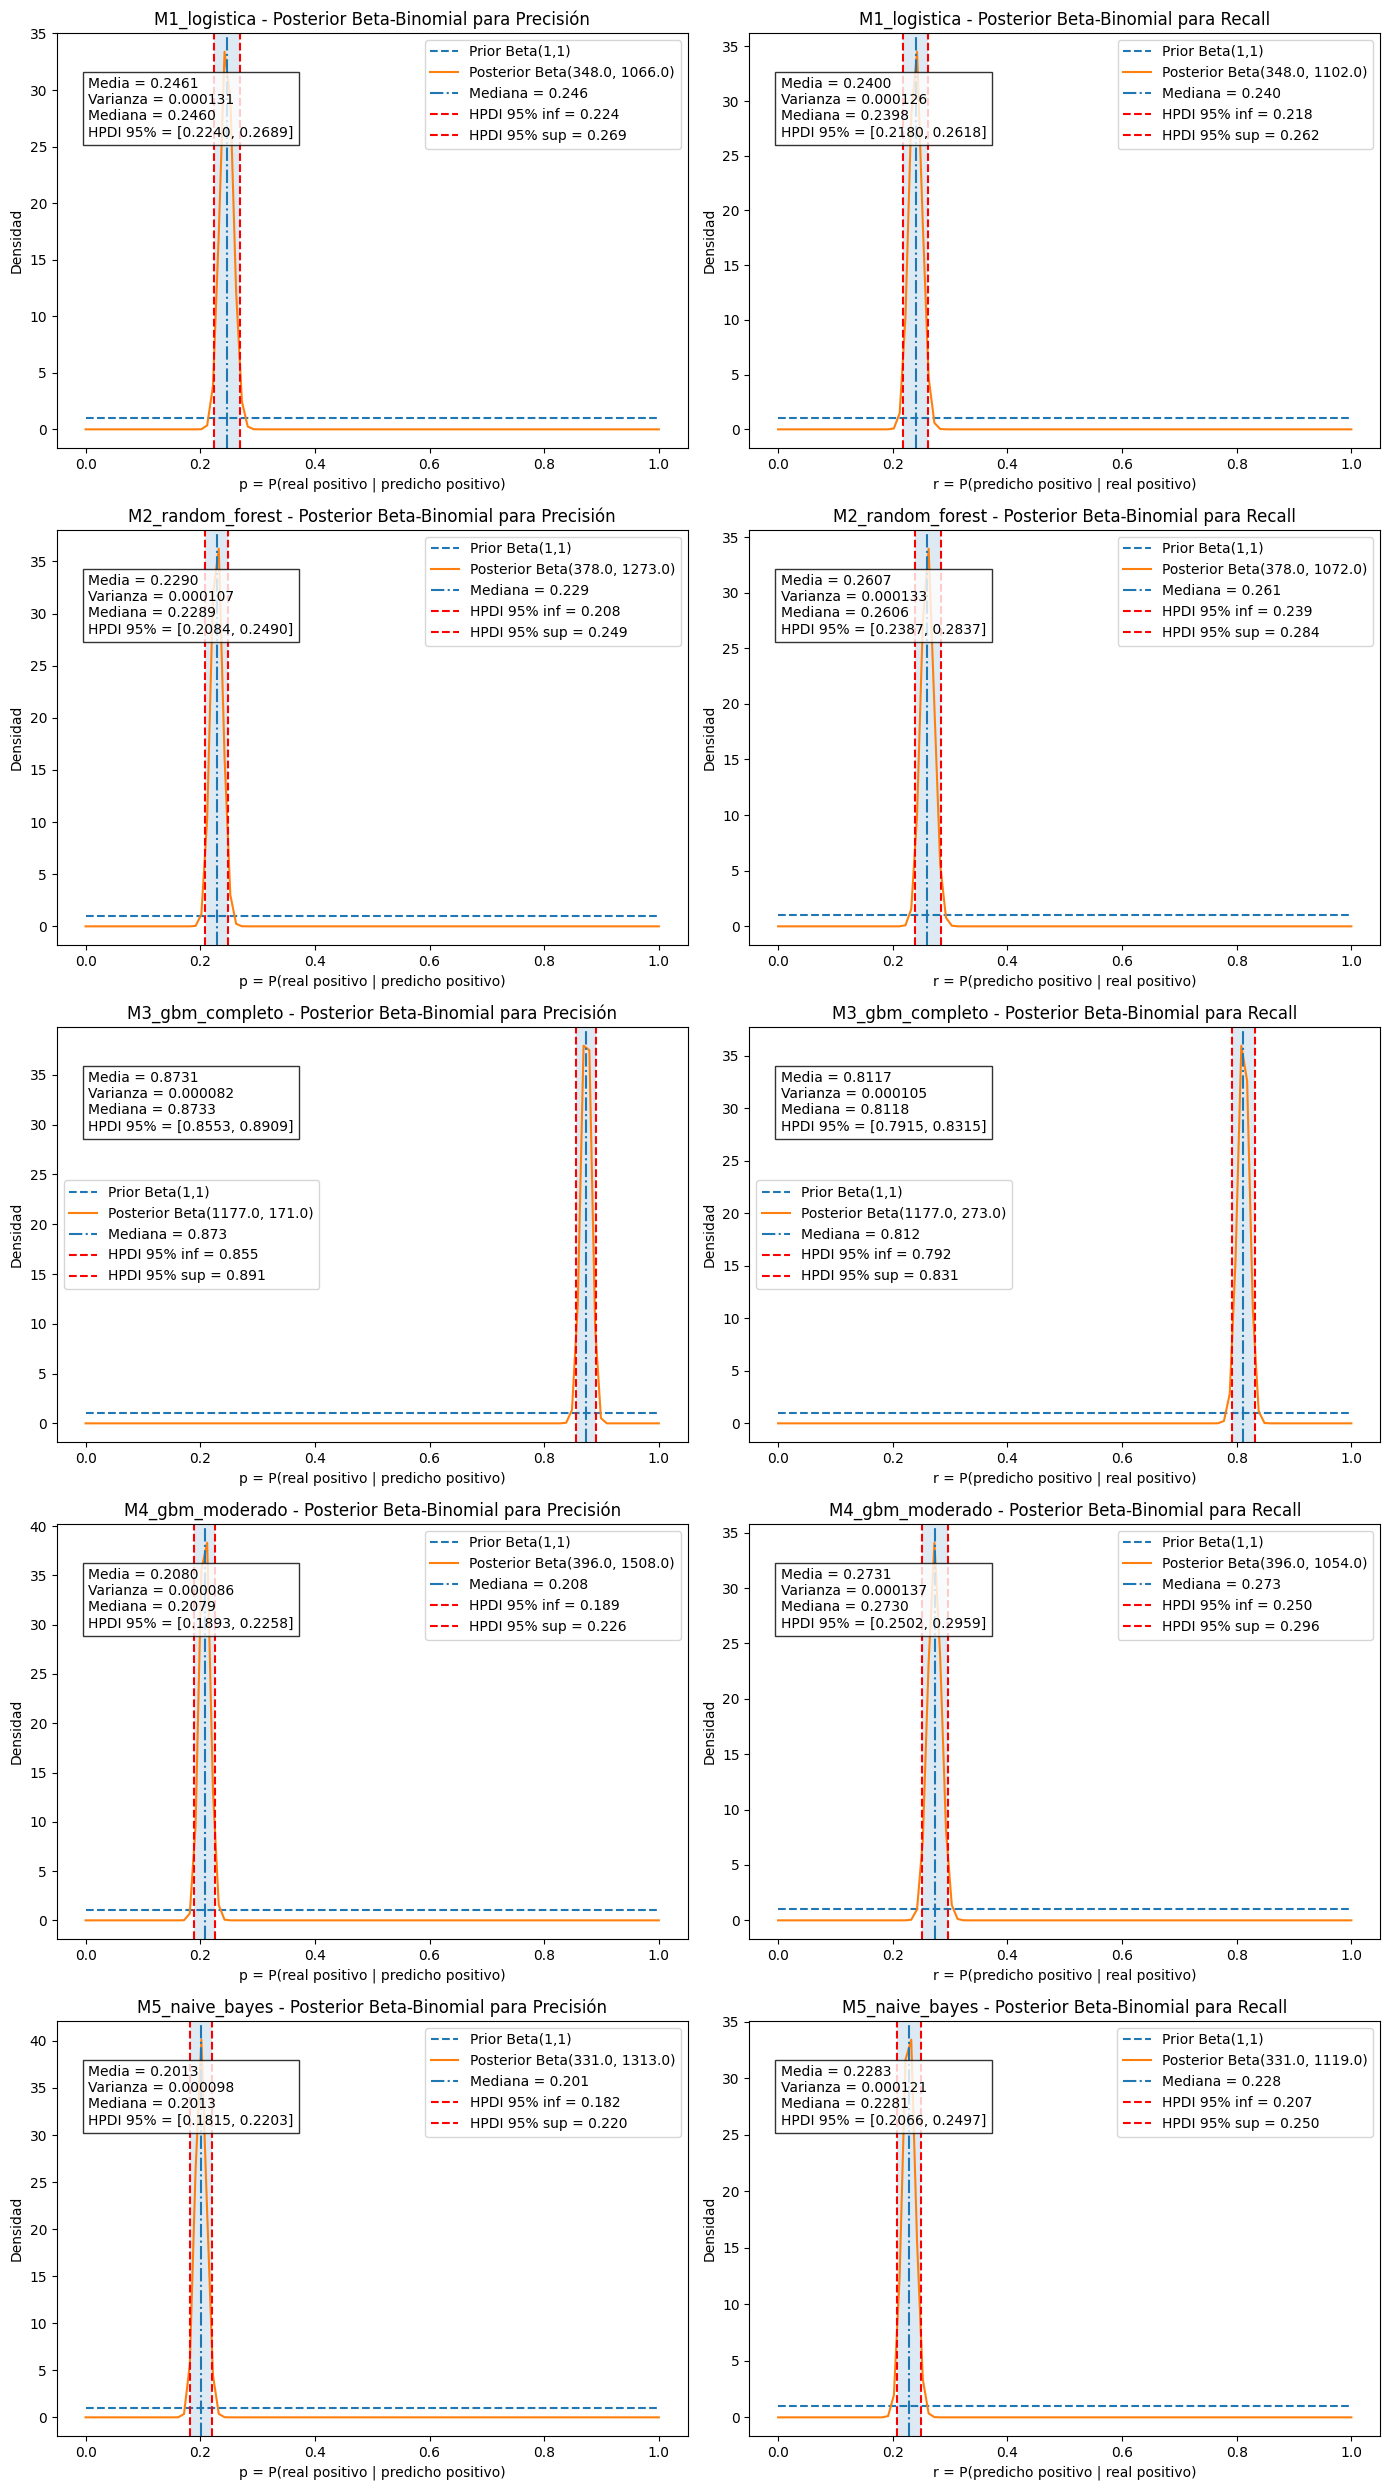

In [28]:
import numpy as np
import matplotlib.pyplot as plt

n_models = len(results)

# Crear figura: una fila por modelo, 2 columnas (Precisión y Recall)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

# Si hay un solo modelo, axes viene como vector de longitud 2.
# Lo convertimos a forma (1, 2) para iterar igual que siempre.
if n_models == 1:
    axes = np.array([axes])

for i, (model, res) in enumerate(results.items()):
    
    # Recuperar valores guardados
    x = res["x"]
    
    prior_P = res["prior_P"]
    posterior_P = res["posterior_P"]
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    mean_P = res["mean_P"]
    var_P = res["var_P"]
    median_P = res["median_P"]
    hpdi_P = res["hpdi_P"]

    prior_R = res["prior_R"]
    posterior_R = res["posterior_R"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]
    mean_R = res["mean_R"]
    var_R = res["var_R"]
    median_R = res["median_R"]
    hpdi_R = res["hpdi_R"]

    # ==========================
    # Columna 1: Precisión
    # ==========================
    ax = axes[i, 0]

    ax.plot(x, prior_P, label="Prior Beta(1,1)", linestyle="--")
    ax.plot(x, posterior_P, label=f"Posterior Beta({a_post_P}, {b_post_P})")

    # Mediana y HPDI
    ax.axvline(median_P, linestyle="-.", label=f"Mediana = {median_P:.3f}")
    ax.axvline(hpdi_P[0], linestyle="--", color="red", label=f"HPDI 95% inf = {hpdi_P[0]:.3f}")
    ax.axvline(hpdi_P[1], linestyle="--", color="red", label=f"HPDI 95% sup = {hpdi_P[1]:.3f}")

    # Opcional: sombrear el HPDI
    ax.axvspan(hpdi_P[0], hpdi_P[1], alpha=0.15)

    # Texto dentro del gráfico
    ax.text(
        0.05, 0.75,
        f"Media = {mean_P:.4f}\n"
        f"Varianza = {var_P:.6f}\n"
        f"Mediana = {median_P:.4f}\n"
        f"HPDI 95% = [{hpdi_P[0]:.4f}, {hpdi_P[1]:.4f}]",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"{model} - Posterior Beta-Binomial para Precisión")
    ax.set_xlabel("p = P(real positivo | predicho positivo)")
    ax.set_ylabel("Densidad")
    ax.legend()

    # ==========================
    # Columna 2: Recall
    # ==========================
    ax = axes[i, 1]

    ax.plot(x, prior_R, label="Prior Beta(1,1)", linestyle="--")
    ax.plot(x, posterior_R, label=f"Posterior Beta({a_post_R}, {b_post_R})")

    # Mediana y HPDI
    ax.axvline(median_R, linestyle="-.", label=f"Mediana = {median_R:.3f}")
    ax.axvline(hpdi_R[0], linestyle="--", color="red", label=f"HPDI 95% inf = {hpdi_R[0]:.3f}")
    ax.axvline(hpdi_R[1], linestyle="--", color="red", label=f"HPDI 95% sup = {hpdi_R[1]:.3f}")

    # Opcional: sombrear el HPDI
    ax.axvspan(hpdi_R[0], hpdi_R[1], alpha=0.15)

    # Texto dentro del gráfico
    ax.text(
        0.05, 0.75,
        f"Media = {mean_R:.4f}\n"
        f"Varianza = {var_R:.6f}\n"
        f"Mediana = {median_R:.4f}\n"
        f"HPDI 95% = [{hpdi_R[0]:.4f}, {hpdi_R[1]:.4f}]",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"{model} - Posterior Beta-Binomial para Recall")
    ax.set_xlabel("r = P(predicho positivo | real positivo)")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

Paso 3. 

Propagación Monte Carlo a F1. F1 no tiene posterior conjugado en forma cerrada porque combina precisión y sensibilidad. 

Se obtiene por simulación: muestrear S ≥ 5 000 valores conjuntos (p (s) , r(s) ), calcular F (s) 1 = 2p (s) r (s)/(p (s) +r (s) ) para cada s, y reportar mediana y HPDI 95 % del vector resultante. Verificar que el HPDI cubra el F1 puntual ≈ 0,842 del paso 1; si no lo cubre, hay un error de cómputo.

In [29]:
import numpy as np
from scipy.stats import beta

# Cantidad de simulaciones
S = 100_000

# Semilla reproducible
rng = np.random.default_rng(42)

for model, res in results.items():

    # Parámetros posteriores de precisión
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]

    # Parámetros posteriores de recall
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    # Simular valores desde las posteriores
    p_samples = beta.rvs(
        a_post_P,
        b_post_P,
        size=S,
        random_state=rng
    )

    r_samples = beta.rvs(
        a_post_R,
        b_post_R,
        size=S,
        random_state=rng
    )

    # Propagación Monte Carlo a F1
    f1_samples = 2 * p_samples * r_samples / (p_samples + r_samples)

    # Guardar en results
    results[model]["p_samples"] = p_samples
    results[model]["r_samples"] = r_samples
    results[model]["f1_samples"] = f1_samples

In [30]:
## Calculamos la media, mediana, varianza y HPDI de F1 para todos los modelos

for model, res in results.items():
    
    f1_samples = res["f1_samples"]
    
    median_f1 = np.median(f1_samples)
    mean_f1 = np.mean(f1_samples)
    var_f1 = np.var(f1_samples)
    hpdi_f1 = hpdi(f1_samples, prob=0.95)
    
    # Guardamos los resultados
    results[model]["median_f1"] = median_f1
    results[model]["mean_f1"] = mean_f1
    results[model]["var_f1"] = var_f1
    results[model]["hpdi_f1"] = hpdi_f1
    
    # Mostramos resultados
    print(f"Modelo: {model}")
    print(f"Media F1: {mean_f1:.4f}")
    print(f"Mediana F1: {median_f1:.4f}")
    print(f"Varianza F1: {var_f1:.8f}")
    print(f"HPDI 95% F1: [{hpdi_f1[0]:.4f}, {hpdi_f1[1]:.4f}]")
    print("-" * 50)

Modelo: M1_logistica
Media F1: 0.2427
Mediana F1: 0.2427
Varianza F1: 0.00006402
HPDI 95% F1: [0.2271, 0.2584]
--------------------------------------------------
Modelo: M2_random_forest
Media F1: 0.2435
Mediana F1: 0.2434
Varianza F1: 0.00005993
HPDI 95% F1: [0.2285, 0.2589]
--------------------------------------------------
Modelo: M3_gbm_completo
Media F1: 0.8413
Mediana F1: 0.8413
Varianza F1: 0.00004851
HPDI 95% F1: [0.8273, 0.8546]
--------------------------------------------------
Modelo: M4_gbm_moderado
Media F1: 0.2359
Mediana F1: 0.2359
Varianza F1: 0.00005497
HPDI 95% F1: [0.2218, 0.2509]
--------------------------------------------------
Modelo: M5_naive_bayes
Media F1: 0.2137
Mediana F1: 0.2136
Varianza F1: 0.00005464
HPDI 95% F1: [0.1992, 0.2281]
--------------------------------------------------


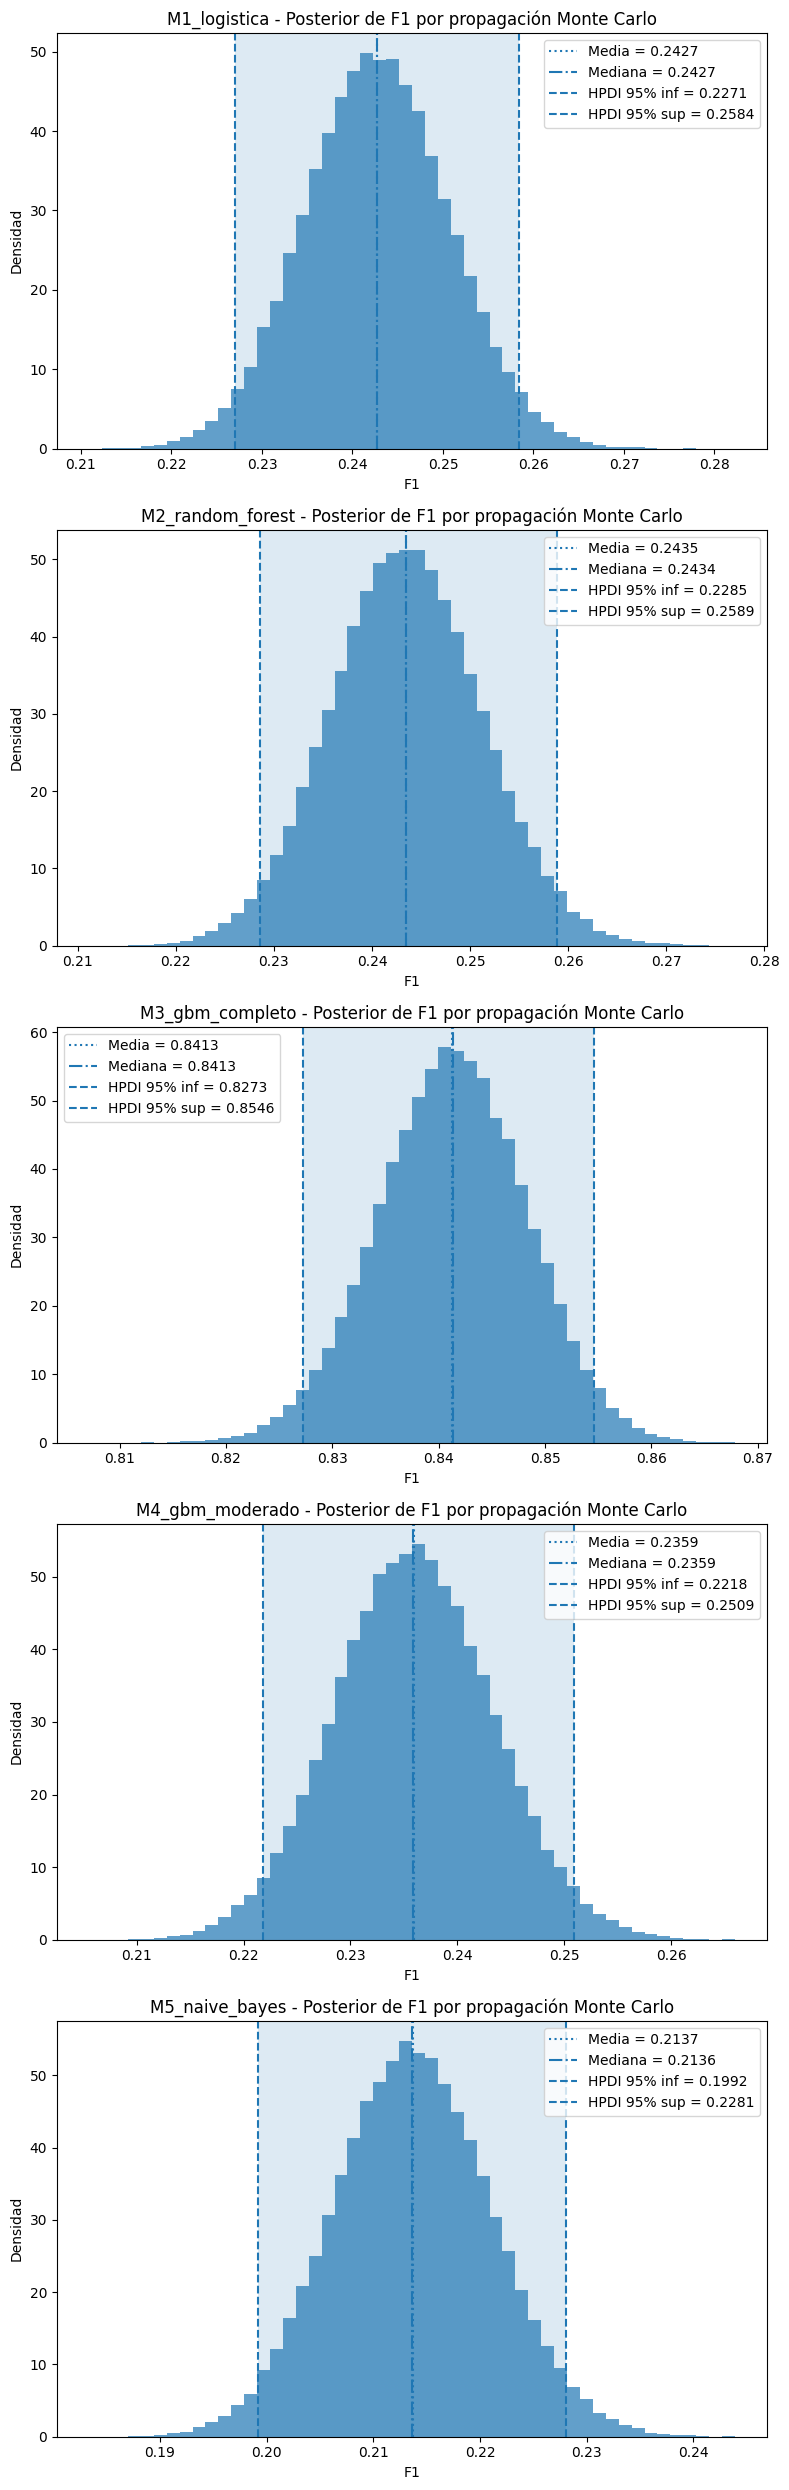

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n_models = len(results)

fig, axes = plt.subplots(n_models, 1, figsize=(8, 5 * n_models))

# Si hay un solo modelo, axes no viene como lista
if n_models == 1:
    axes = [axes]

for ax, (model, res) in zip(axes, results.items()):
    
    f1_samples = res["f1_samples"]
    mean_f1 = res["mean_f1"]
    median_f1 = res["median_f1"]
    var_f1 = res["var_f1"]
    hpdi_f1 = res["hpdi_f1"]

    ax.hist(f1_samples, bins=50, density=True, alpha=0.7)

    ax.axvline(mean_f1, linestyle=":", label=f"Media = {mean_f1:.4f}")
    ax.axvline(median_f1, linestyle="-.", label=f"Mediana = {median_f1:.4f}")
    ax.axvline(hpdi_f1[0], linestyle="--", label=f"HPDI 95% inf = {hpdi_f1[0]:.4f}")
    ax.axvline(hpdi_f1[1], linestyle="--", label=f"HPDI 95% sup = {hpdi_f1[1]:.4f}")

    # Sombrear el HPDI
    ax.axvspan(hpdi_f1[0], hpdi_f1[1], alpha=0.15)

    # Texto dentro del gráfico

    

    ax.set_title(f"{model} - Posterior de F1 por propagación Monte Carlo")
    ax.set_xlabel("F1")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

Paso 4. Replicar el procedimiento sobre los cinco modelos
Repetir los pasos 2 y 3 para M1, . . . , M5 sobre T0 entera. Producir una tabla con cinco filas (un
modelo por fila) y tres columnas: mediana F1, HPDI 95 % y conteos. Esa tabla es el primer panel
del análisis bayesiano y reconstruye, con incertidumbre cuantificada, la decisión que el banco
tomó en 2024 al elegir M3. Conviene comprobar que la mediana de M3 supera con holgura a las
de los otros cuatro: en T0 entera, M3 era efectivamente el modelo dominante.

### Tabla con 5 filas

In [32]:
# Producir una tabla con cinco filas (un
# modelo por fila) y tres columnas: mediana F1, HPDI 95 % y conteos.

Bayesian_table = pd.DataFrame({
    "Modelo": [],
    "Mediana F1": [],
    "HPDI 95%": [],
    "Conteos": []
})



for model, res in results.items():
    Bayesian_table = pd.concat([Bayesian_table, pd.DataFrame({
        "Modelo": [model],
        "Mediana F1": [f"{res['median_f1']:.4f}"],
        "HPDI 95%": [f"[{res['hpdi_f1'][0]:.4f}, {res['hpdi_f1'][1]:.4f}]"],
        "Conteos": [f"TP={res['TP']}, FP={res['FP']}, FN={res['FN']}"]
    })], ignore_index=True)


Bayesian_table




,Modelo,Mediana F1,HPDI 95%,Conteos
0,M1_logistica,0.2427,"[0.2271, 0.2584]","TP=347.0, FP=1065.0, FN=1101.0"
1,M2_random_forest,0.2434,"[0.2285, 0.2589]","TP=377.0, FP=1272.0, FN=1071.0"
2,M3_gbm_completo,0.8413,"[0.8273, 0.8546]","TP=1176.0, FP=170.0, FN=272.0"
3,M4_gbm_moderado,0.2359,"[0.2218, 0.2509]","TP=395.0, FP=1507.0, FN=1053.0"
4,M5_naive_bayes,0.2136,"[0.1992, 0.2281]","TP=330.0, FP=1312.0, FN=1118.0"


In [33]:
# Primer panel del análisis bayesiano y reconstruye, con incertidumbre cuantificada, la decisión que el banco tomó en 2024 al elegir M3.

# HPDI: Highest Posterior Density Interval. The 95% most probable values of a parameter. Mientras más estrecho menos incertidumbre del posible valor del parámetro.

# Mediana: ¿La masa de una distribución está centrada alrededor de un valor alto o bajo? Si es alto nos está diciendo que el modelo tiene un buen desempeño, si es bajo nos está diciendo que el modelo tiene un mal desempeño.





In [ ]:
print("probando")